In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Load THe Data Set 

In [2]:
df=pd.read_csv('credit_fraud.csv')
df.head()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41.0,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2,0
1,49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1
2,38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0
3,38.0,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1
4,61.0,12914.13,2013.73,34.0,0.0,NaN,0.0,4366.7,9.7,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32300 entries, 0 to 32299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     31656 non-null  str    
 1   transaction_amount      31653 non-null  float64
 2   account_balance         31655 non-null  float64
 3   num_transactions_today  31654 non-null  float64
 4   is_foreign_transaction  31649 non-null  float64
 5   transaction_hour        31657 non-null  float64
 6   prev_fraud_flag         31654 non-null  float64
 7   merchant_distance_km    31657 non-null  float64
 8   merchant_risk_score     31656 non-null  float64
 9   is_fraud                32300 non-null  int64  
dtypes: float64(8), int64(1), str(1)
memory usage: 2.5 MB


##  Age in this Dataset is String Covert into int

In [4]:
df['age']=pd.to_numeric(df['age'],errors='coerce')

# Check the Dublicate Values

In [5]:
# in this data set duplication are mendentary because there are not uniques element so not remove it

In [6]:
# df.drop_duplicates(inplace=True)

# Separate Numerical and Categorical Data

In [7]:
numeric=df.select_dtypes(include=['object'])
categoric=df.select_dtypes(include=['int64','float64'])

# check Null Values and Remove it

In [8]:
per=(df.isnull().sum()*100/df.shape[0]).reset_index()
per

# contain Large amount of Null values so we can Fill it


,index,0
0,age,2.241486
1,transaction_amount,2.003096
2,account_balance,1.996904
3,num_transactions_today,2.000000
4,is_foreign_transaction,2.015480
5,transaction_hour,1.990712
6,prev_fraud_flag,2.000000
7,merchant_distance_km,1.990712
8,merchant_risk_score,1.993808
9,is_fraud,0.000000


In [9]:
df=df.fillna(df.mean(),inplace=True)


In [10]:
df.describe()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
count,32300.000000,32300.000000,32300.000000,32300.000000,32300.000000,32300.000000,32300.000000,32300.000000,32300.000000,32300.000000
mean,46.061154,7471.580234,25020.772509,24.924591,0.145818,11.466532,0.081032,2500.266033,5.512513,0.481734
std,16.289192,4280.598768,14279.003787,14.008453,0.349355,6.850852,0.270146,1430.286680,2.568919,0.499674
min,-10.000000,1.070000,-99999.000000,1.000000,0.000000,0.000000,0.000000,0.100000,1.000000,0.000000
25%,32.000000,3805.575000,12758.177500,13.000000,0.000000,6.000000,0.000000,1277.575000,3.300000,0.000000
50%,46.061154,7471.580234,25020.772509,24.924591,0.000000,11.466532,0.000000,2500.266033,5.512513,0.000000
75%,60.000000,11132.350000,37287.985000,37.000000,0.000000,17.000000,0.000000,3716.875000,7.700000,1.000000
max,74.000000,14999.710000,49998.900000,49.000000,1.000000,28.000000,1.000000,4999.800000,15.000000,1.000000


# Outlier Detection

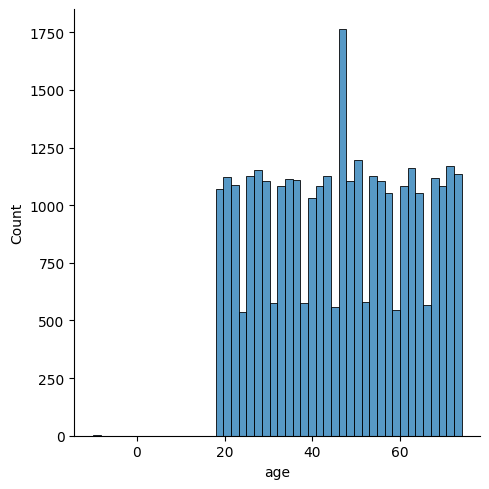

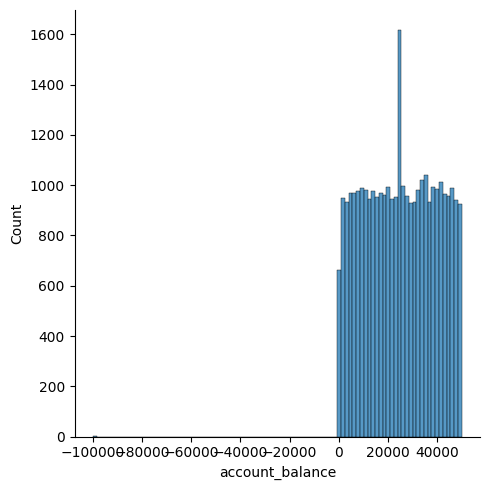

In [11]:
plt.Figure(figsize=(16,5))
print(sns.displot(df['age']))
print(sns.displot(df['account_balance']))



    

In [12]:
# Q1,Q3=np.percentile(df['age'],[25,75])
# IQR=Q3-Q1

# lower_limit=Q1 -1.5 * IQR
# upper_limit = Q3 - 1.5 * IQR
# df=df[(df['age'] >= lower_limit) & (df['age'] <= upper_limit)]

In [13]:
# if data set cotain negtive values first change in to null and fillna 
df[df['age'] < 0]=np.nan
df['age'].fillna(df['age'].mean(),inplace=True)
df[df['account_balance'] < 0]=np.nan
df['account_balance'].fillna(df['account_balance'].mean(),inplace=True)


C:\Users\Muhammad Adnan\AppData\Local\Temp\ipykernel_18420\2934941261.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['age'].fillna(df['age'].mean(),inplace=True)
C:\Users\Muhammad Adnan\AppData\Local\Temp\ipykernel_18420\2934941261.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through c

0        12686.50
1        36337.02
2        23295.64
3        38586.08
4         2013.73
           ...   
32295     7657.07
32296    22418.91
32297    43444.14
32298    12451.13
32299    27752.37
Name: account_balance, Length: 32300, dtype: float64

In [14]:
df.describe()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
count,32298.000000,32298.000000,32298.000000,32298.000000,32298.000000,32298.000000,32298.000000,32298.000000,32298.000000,32298.000000
mean,46.063728,7471.229196,25024.949605,24.924308,0.145827,11.466344,0.081037,2500.213080,5.512582,0.481733
std,16.286013,4280.476417,14262.383522,14.008495,0.349364,6.850886,0.270154,1430.267563,2.568852,0.499674
min,18.000000,1.070000,0.230000,1.000000,0.000000,0.000000,0.000000,0.100000,1.000000,0.000000
25%,32.000000,3805.465000,12758.460000,13.000000,0.000000,6.000000,0.000000,1277.525000,3.300000,0.000000
50%,46.061154,7471.580234,25020.772509,24.924591,0.000000,11.466532,0.000000,2500.266033,5.512513,0.000000
75%,60.000000,11131.880000,37288.575000,37.000000,0.000000,17.000000,0.000000,3716.750000,7.700000,1.000000
max,74.000000,14999.710000,49998.900000,49.000000,1.000000,28.000000,1.000000,4999.800000,15.000000,1.000000


<Axes: >

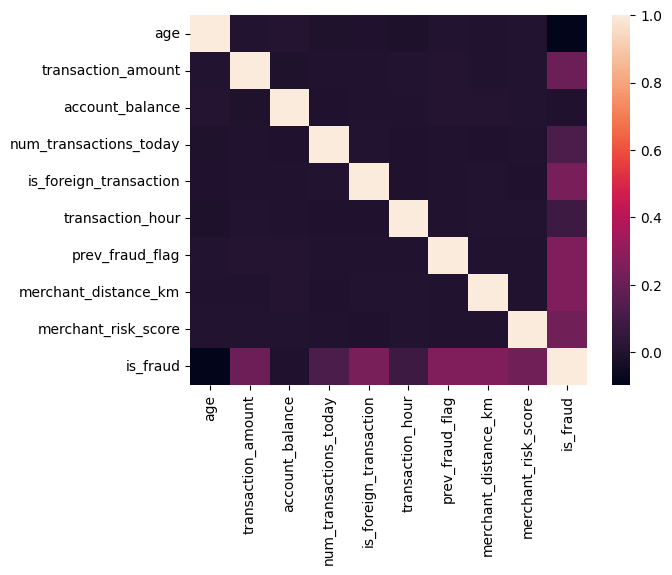

In [15]:
corr=df.corr()
corr
sns.heatmap(corr)

<Axes: xlabel='is_fraud'>

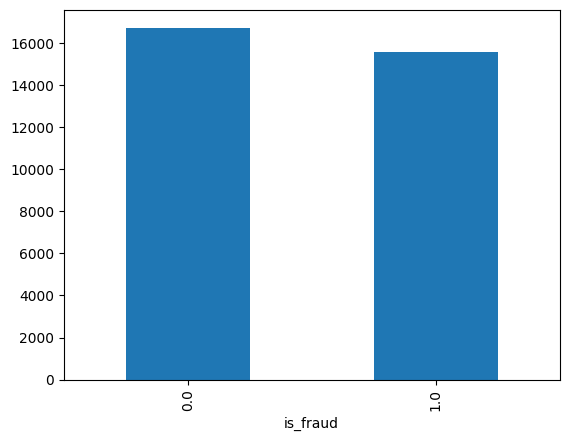

In [16]:
df['is_fraud'].value_counts().plot(kind='bar')

In [17]:
df.columns

Index(['age', 'transaction_amount', 'account_balance',
       'num_transactions_today', 'is_foreign_transaction', 'transaction_hour',
       'prev_fraud_flag', 'merchant_distance_km', 'merchant_risk_score',
       'is_fraud'],
      dtype='str')

In [18]:
df.dropna(inplace=True)


In [19]:
df.head(11)

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41.000000,2453.810000,12686.50,21.0,0.000000,9.000000,0.0,2438.2,5.200000,0.0
1,49.000000,1574.120000,36337.02,37.0,0.000000,4.000000,0.0,2967.1,8.400000,1.0
2,38.000000,14897.420000,23295.64,21.0,0.000000,0.000000,0.0,4703.6,3.700000,0.0
3,38.000000,9927.230000,38586.08,46.0,0.000000,17.000000,0.0,4281.2,5.500000,1.0
4,61.000000,12914.130000,2013.73,34.0,0.000000,11.466532,0.0,4366.7,9.700000,1.0
6,42.000000,9588.280000,22616.51,35.0,0.000000,19.000000,0.0,2910.5,9.800000,1.0
7,46.061154,40.920000,46219.22,25.0,0.000000,10.000000,0.0,3379.9,7.900000,1.0
8,50.000000,4442.560000,4569.65,14.0,0.000000,2.000000,0.0,1751.0,3.500000,0.0
9,57.000000,14993.400000,27362.70,8.0,0.145818,9.000000,1.0,3759.3,6.700000,1.0
10,71.000000,7471.580234,41384.22,45.0,1.000000,18.000000,0.0,1137.8,9.200000,1.0


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
df['is_fraud'].astype('int64')


0        0
1        1
2        0
3        1
4        1
        ..
32295    0
32296    1
32297    0
32298    0
32299    0
Name: is_fraud, Length: 32298, dtype: int64

In [21]:
X=df.drop(columns=['is_fraud']) # ------> independent Fature
Y=df['is_fraud']  # ---Target Output
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=43)
model=DecisionTreeClassifier(criterion="entropy")
model.fit(X_train,Y_train)
predictive=model.predict(X_test)



In [22]:
print(f"Accuracy:{accuracy_score(Y_test,predictive)}")
print(classification_report(Y_test,predictive))
print(confusion_matrix(Y_test,predictive))

Accuracy:0.6652218782249743
              precision    recall  f1-score   support

         0.0       0.68      0.67      0.68      5053
         1.0       0.65      0.66      0.65      4637

    accuracy                           0.67      9690
   macro avg       0.66      0.66      0.66      9690
weighted avg       0.67      0.67      0.67      9690

[[3395 1658]
 [1586 3051]]


<Axes: xlabel='is_foreign_transaction', ylabel='count'>

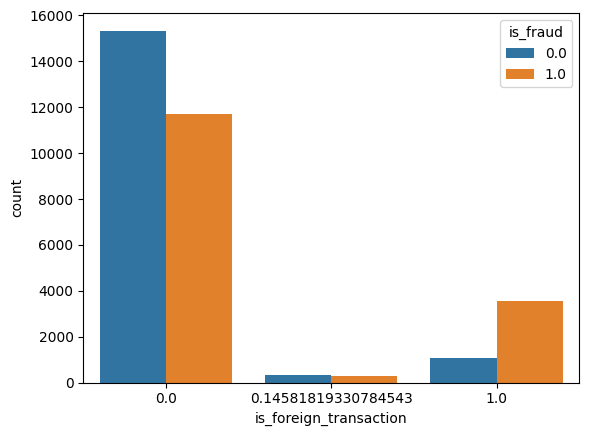

In [23]:
sns.countplot(data=df, x=df['is_foreign_transaction'],hue=df['is_fraud'])

In [ ]:

sns.countplot(data=df ,x=df['account_balance'] , hue=df['is_fraud'])

<Axes: xlabel='account_balance', ylabel='count'>

d:\Mechine_Learning\venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
